# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [1]:
# Импортируем необходимые библиотеки из sklearn
# CountVectorizer преобразует текстовые данные в матрицу частот слов (Bag of Words)
from sklearn.feature_extraction.text import CountVectorizer
# accuracy_score вычисляет точность модели, сравнивая предсказанные и реальные метки
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
# train_test_split делит данные на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split, GridSearchCV
# MultinomialNB — наивный байесовский классификатор для дискретных данных (например, частот слов)
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import roc_curve, auc

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Загружаем датасет
data = pd.read_csv('Data/spam_or_not_spam.csv')

# Выводим первые пять строк
display(data.head(5))
# Проверяем есть ли пропуски
display(f'Количество пропусков в данных: {data.isnull().sum().sum()}')

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


'Количество пропусков в данных: 1'

In [3]:
# Считаем количество спама и не спама
print(f'Количество спама и неспама: {data["label"].value_counts()}')

Количество спама и неспама: label
0    2500
1     500
Name: count, dtype: int64


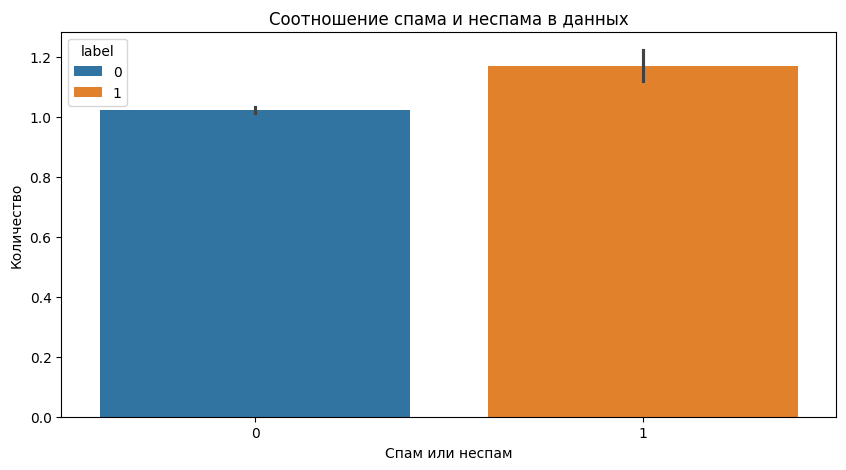

In [4]:
# Выведим в графике количество спам и не спам сообщений
grouped_data = data.groupby('label').value_counts().reset_index()
# Создаем фигуру для графика с размером (10, 5)
fig, axes = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=grouped_data,
    x='label',
    y='count',
    hue='label',
    ax=axes)

# Устанавливаем метки для осей X и Y графика
axes.set_title('Соотношение спама и неспама в данных')
axes.set(xlabel='Спам или неспам', ylabel='Количество')

plt.show()

## Задание 2 (2 балла)

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [5]:
# Удаление всех неалфавитных символов (кроме пробела) в столбце 'SMS' и приведение текста к нижнему регистру
data["email"] = data["email"].str.replace(r"\W+", " ", regex=True).str.lower()
# Замена множества пробелов на один пробел и удаление лишних пробелов в начале и конце строки
data['email'] = data['email'].str.replace(r'\s+', ' ', regex=True).str.strip()
# Приведение текста в столбце 'SMS' снова к нижнему регистру (для консистентности)
data['email'] = data['email'].str.lower()

# Поскольку в данных имеется пропуск попробуем его обработать, чтобы векторизатор смог обработать данные
# Удаляем строки с NaN значениями в столбце 'email'
data = data.dropna(subset=['email'])

# Также удаляем строки с пустыми значениями или пробелами в тексте
data = data[data['email'].str.strip().ne('')]

Переводим данные в векторный вид:

In [6]:
# Создание экземпляра векторизатора для преобразования текста в числовые векторы (мешок слов)
vectorizer = CountVectorizer()

# Применение векторизатора к столбцу 'email' и преобразование текста в числовые представления
X_vectoirized = vectorizer.fit_transform(data['email'])

Определите, сколько теперь признаков в нашем наборе данных:

Количество признаков: 34116


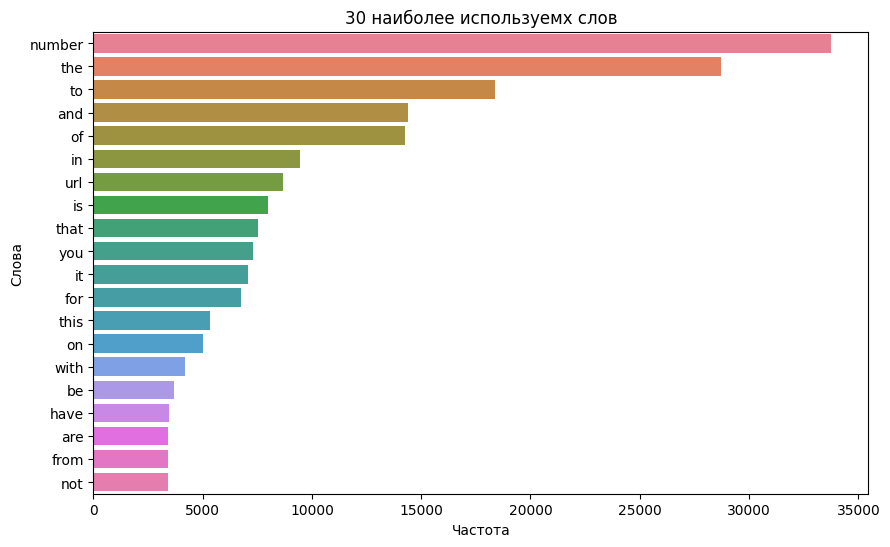

In [7]:
# Количество признаков
print(f"Количество признаков: {X_vectoirized.shape[1]}")

# Получаем список всех слов (терминов) из словаря
terms = vectorizer.get_feature_names_out()

# Считаем частоту появления каждого термина во всем корпусе
word_counts = np.asarray(X_vectoirized.sum(axis=0)).flatten()  # Суммируем по всем строкам
term_frequencies = dict(zip(terms, word_counts))  # Создаем словарь {слово: частота}

# Получаем 20 наиболее частых слов
top_30_terms = sorted(term_frequencies.items(), key=lambda x: x[1], reverse=True)[:20]

# Разделяем на списки для визуализации
words, frequencies = zip(*top_30_terms)

# Визуализируем на графике
fig, axes = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=list(frequencies), 
    y=list(words),
    hue=words,
    ax=axes)

# Устанавливаем метки для осей X и Y графика
axes.set_title('30 наиболее используемх слов')
axes.set(xlabel='Частота', ylabel='Слова')

plt.show()

## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [8]:
# Присваивание меток (классов) из столбца 'label' в отдельную переменную y
y = data['label']

print(f"Размер X: {X_vectoirized.shape}")
print(f"Размер y: {y.shape}")

Размер X: (2997, 34116)
Размер y: (2997,)


Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectoirized,
    y,
    test_size=0.25,
    train_size=0.75,
    stratify=y,
    random_state=42
    )

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [10]:
print(f'Среднее значение для целевой переменной (тестовая выборка): {y_test.mean():.3f}')

Среднее значение для целевой переменной (тестовая выборка): 0.165


## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [11]:
# Создание экземпляра классификатора Naive Bayes для многоклассовой классификации (ComplementNB)
complement_model = ComplementNB(alpha=0.01)

# Обучение классификатора на обучающих данных (X_train и y_train)
complement_model.fit(X_train, y_train)

# Прогнозирование меток на тестовых данных (X_test)
y_test_pred = complement_model.predict(X_test)

# Вычисление метрик с учетом несбалансированных классов
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

# Вычисление и вывод точности модели, сравнивая предсказания с истинными метками тестовой выборки
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")

Accuracy: 0.988
Precision: 1.000


Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [12]:
# Вывод результатов
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Accuracy: 0.988
Precision: 1.000
Recall: 0.927
F1-score: 0.962


# Вывод
Метрика Precision (точность) кажется идеальной и может намекать на переобучение. Метрики recall и f1-score показали достаточно высокие значения, но возможно их стоит улучшить.

Нарисуйте ROC-кривую:

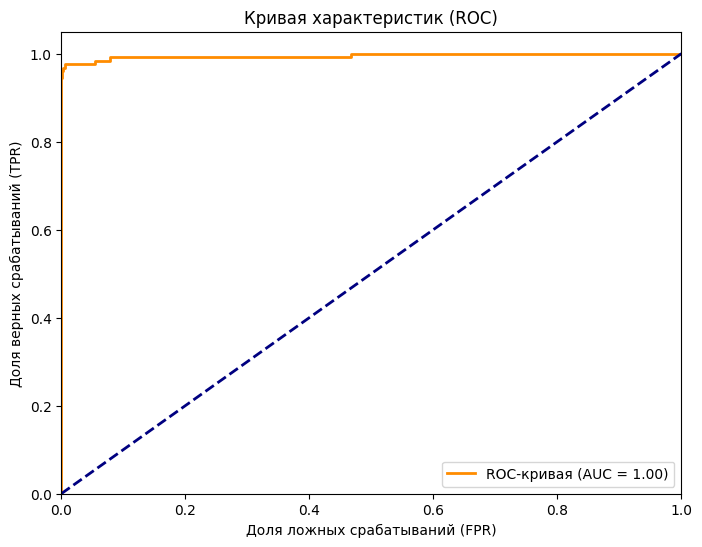

In [13]:
# Прогнозирование вероятностей (для бинарной классификации)
y_prob = complement_model.predict_proba(X_test)[:, 1]  # Вероятности для положительного класса

# Вычисление ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Вычисление AUC
roc_auc = auc(fpr, tpr)

# Построение ROC-кривой
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Линия случайного классификатора
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Доля ложных срабатываний (FPR)')
plt.ylabel('Доля верных срабатываний (TPR)')
plt.title('Кривая характеристик (ROC)')
plt.legend(loc='lower right')
plt.show()

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [14]:
# Инициализация классификатора Complement Naive Bayes (ComplementNB)
complement_model = ComplementNB()

# Определяем сетку параметров для поиска по сетке (GridSearch) - в данном случае только для параметра 'alpha'
param_grid = {'alpha': [0.01, 0.1, 0.5, 1, 2, 5, 10]}

# Инициализация поиска по сетке с использованием кросс-валидации (cv=5) и метрики точности (accuracy)
grid_search = GridSearchCV(
    estimator=complement_model,  # классификатор
    param_grid=param_grid,       # сетка параметров для подбора
    cv=5,                        # количество фолдов для кросс-валидации
    scoring=make_scorer(accuracy_score)  # метрика, используемая для оценки модели (accuracy)
)

# Обучение модели на обучающей выборке с кросс-валидацией для подбора оптимального параметра 'alpha'
grid_search.fit(X_train, y_train)

# Лучший параметр alpha и соответствующий результат
print(f"Лучший параметр alpha: {grid_search.best_params_['alpha']}")
print(f"Лучший результат (accuracy): {grid_search.best_score_:.3f}")
print()

# Прогнозирование на тестовой выборке с оптимальным параметром alpha
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Оценка качества модели на тестовой выборке
print(f"Accuracy на тестовой выборке: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision на тестовой выборке: {precision_score(y_test, y_pred):.3f}")
print(f"Recall на тестовой выборке: {recall_score(y_test, y_pred):.3f}")
print(f"F1-Score на тестовой выборке: {f1_score(y_test, y_pred):.3f}")

Лучший параметр alpha: 0.5
Лучший результат (accuracy): 0.991

Accuracy на тестовой выборке: 0.995
Precision на тестовой выборке: 0.992
Recall на тестовой выборке: 0.976
F1-Score на тестовой выборке: 0.984


# Вывод:

Результаты показывают, что после кросс-валидации с оптимизацией параметров модель улучшила свои показатели.
Сравнивая результаты, мы можем сказать, что метрики качества на тестовой выборке улучшились благодаря кросс-валидации.

После кросс-валидации (точность, полнота, F1-метрика) по сравнению с исходной моделью.

- Accuracy повысилась с 0.988 до 0.995.
- Precision и Recall (с 1.000 до 0.992 и с 0.927 до 0.976 соответственно). 
- F1-score стал выше (с 0.962 до 0.984).

Несмотря на то, что точность (precision) чуть упала остальные метрики стали выше и модель стала более сбалансированной.